
  a)  Build KNN Classification model for a given dataset. Vary the number of k values as follows and compare the results:     i. 1      ii. 3      iii.5      iv. 7      v.11
    
  b)  Implement Support Vector Machine for a dataset and compare the accuracy by applying the following kernel   functions:     i. Linear      ii. Polynomial        iii.RBF
    
  c) Write a python program to implement K-Means clustering Algorithm. Vary the number of k values as follows and compare the results:     i. 1      ii. 3      iii.5      iv. 7    **



# **Machine Learning: KNN, SVM and K-Means**
**Dataset: Wine Quality (Red Wine) from Kaggle**

**Link:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

In [7]:
#  Importing all required libraries for KNN, SVM, K-Means and plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.svm            import SVC
from sklearn.cluster        import KMeans
from sklearn.metrics        import accuracy_score, silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Loading the Wine Quality dataset from CSV file

df = pd.read_csv('/content/winequality-red.csv')
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (1599, 12)

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5 

In [8]:
#  Preprocessing data — binarize quality into 'good' (>=7) and 'bad' (<7)
# This converts the multi-class problem into a binary classification task
df['label'] = (df['quality'] >= 7).astype(int)

X = df.drop(columns=['quality', 'label'])  # 11 input features
y = df['label']                               # binary target: 0=bad, 1=good

# Split into 80% train and 20% test set with fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features using StandardScaler (zero mean, unit variance)
# Scaling is critical for distance-based models like KNN and SVM
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Good wines in test: {y_test.sum()}, Bad: {(y_test==0).sum()}")

Training samples : 1279
Testing  samples : 320
Good wines in test: 47, Bad: 273


# **7. a) K-Nearest Neighbors Classifier**
KNN classifies a sample by majority vote among its K nearest neighbors.

We try K = 1, 3, 5, 7, 11 and record accuracy for each value.

In [9]:
# Training KNN model for each K value and record accuracy
# KNeighborsClassifier uses Euclidean distance by default (minkowski p=2)
k_values      = [1, 3, 5, 7, 11]
knn_accuracies = []

print(f"{'K Value':12} {'Correct':12} {'Accuracy'}")
print("-" * 38)

for k in k_values:
    # Instantiate the KNN classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model on training data
    knn.fit(X_train, y_train)

    # Predict labels on unseen test data
    y_pred = knn.predict(X_test)

    # Compute accuracy: fraction of correct predictions
    acc    = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)

    correct = int(acc * len(y_test))
    print(f"K = {k:8} {correct:12} {acc * 100:.2f}%")

K Value      Correct      Accuracy
--------------------------------------
K =        1          285 89.06%
K =        3          279 87.19%
K =        5          282 88.12%
K =        7          284 88.75%
K =       11          281 87.81%


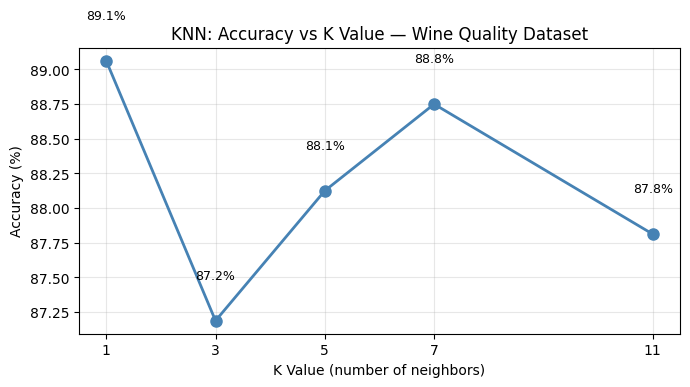

In [10]:
#  Ploting accuracy vs K to visualise the effect of neighbourhood size
# A smaller K = low bias high variance; larger K = smoother but may underfit
plt.figure(figsize=(7, 4))
plt.plot(k_values, [a*100 for a in knn_accuracies],
         marker='o', color='steelblue', linewidth=2, markersize=8)

# Annotating each point with its accuracy percentage
for k, acc in zip(k_values, knn_accuracies):
    plt.text(k, acc*100+0.3, f'{acc*100:.1f}%', ha='center', fontsize=9)

plt.xlabel('K Value (number of neighbors)')
plt.ylabel('Accuracy (%)')
plt.title('KNN: Accuracy vs K Value — Wine Quality Dataset')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# summary comparison table for all K values
print("\nKNN Results Summary")
print("-" * 35)
print(f"{'     K':6} {'        Accuracy':15} {'   Remark'}")
print("-" * 35)
best_k = k_values[knn_accuracies.index(max(knn_accuracies))]
for k, acc in zip(k_values, knn_accuracies):
    remark = "    Best" if k == best_k else ""
    print(f"{k:6} {acc*100:14.2f}% {remark}")


KNN Results Summary
-----------------------------------
     K         Accuracy    Remark
-----------------------------------
     1          89.06%     Best
     3          87.19% 
     5          88.12% 
     7          88.75% 
    11          87.81% 


# **7. b) Support Vector Machine with Kernel Functions**
SVM finds the optimal hyperplane that best separates classes with maximum margin.

* Linear kernel — works best when data is linearly separable.

* Poly kernel  — maps data to higher dimensions using polynomial features

* RBF kernel   — Gaussian kernel, handles non-linear boundaries, most versatile

In [20]:
kernels        = ['linear', 'poly', 'rbf']
kernel_labels  = ['Linear', 'Polynomial', 'RBF']
svm_accuracies = []

print(f"{'Kernel':15} {'Correct':12} {'Accuracy'}")
print("-" * 40)

for kernel, label in zip(kernels, kernel_labels):
    # Instantiate SVM with the selected kernel; C=1 is default regularization
    svm = SVC(kernel=kernel, C=1, random_state=42)

    # Train the SVM on the scaled training set
    svm.fit(X_train, y_train)

    # Predict class labels for the test set
    y_pred = svm.predict(X_test)

    # Calculate accuracy score
    acc    = accuracy_score(y_test, y_pred)
    svm_accuracies.append(acc)

    correct = int(acc * len(y_test))
    print(f"{label:15} {correct:12} {acc * 100:.2f}%")

Kernel          Correct      Accuracy
----------------------------------------
Linear                   273 85.31%
Polynomial               281 87.81%
RBF                      280 87.50%


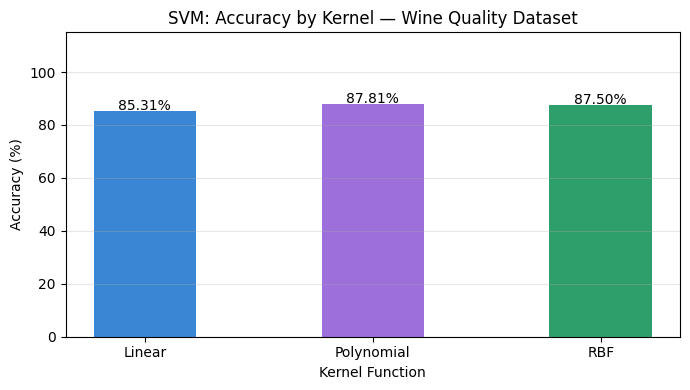

In [21]:
#  Plotting bar chart comparing SVM kernel accuracies

colors = ['#3a86d4', '#9c6fdb', '#2e9e6b']

plt.figure(figsize=(7, 4))
bars = plt.bar(kernel_labels,
               [a*100 for a in svm_accuracies],
               color=colors, width=0.45, edgecolor='none')

# Annotate accuracy value on each bar
for bar, acc in zip(bars, svm_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{acc*100:.2f}%',
        ha='center', fontsize=10
    )

plt.xlabel('Kernel Function')
plt.ylabel('Accuracy (%)')
plt.title('SVM: Accuracy by Kernel — Wine Quality Dataset')
plt.ylim(0, 115)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Printing SVM comparison summary with best kernel highlighted
print("\nSVM Kernel Comparison Summary")
print("=" * 40)
print(f"{'Kernel':15} {'         Accuracy':15} {'  Remark'}")
print("-" * 40)
best_svm = kernel_labels[svm_accuracies.index(max(svm_accuracies))]
for label, acc in zip(kernel_labels, svm_accuracies):
    remark = "    Best" if label == best_svm else ""
    print(f"{label:15} {acc*100:14.2f}% {remark}")


SVM Kernel Comparison Summary
Kernel                   Accuracy   Remark
----------------------------------------
Linear                   85.31% 
Polynomial               87.81%     Best
RBF                      87.50% 


# **7. c) K-Means Clustering**
K-Means partitions data into K clusters by minimizing within-cluster sum of squared distances.

We'll try K = 1, 3, 5, 7 and compare Inertia (elbow) and Silhouette Score.

In [30]:
# Cell 10: Preparing feature matrix for clustering

X_cluster = StandardScaler().fit_transform(
    df.drop(columns=['quality', 'label'])
)
print("Clustering feature matrix shape:", X_cluster.shape)

Clustering feature matrix shape: (1599, 11)


In [39]:
# Running K-Means for K = 1, 3, 5, 7 and collect inertia and silhouette scores


k_values_c = [1, 3, 5, 7]
inertias   = []
sil_scores = []

print(f"{'K':6} {'Inertia':18} {'Silhouette Score'}")
print("-" * 45)

for k in k_values_c:

    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)

    inertia = km.inertia_
    inertias.append(inertia)

    if k > 1:

        sil = silhouette_score(X_cluster, labels)
        sil_scores.append(sil)
        print(f"{k:6} {inertia:18.3f} {sil:.4f}")
    else:
        sil_scores.append(None)          # silhouette not applicable for K=1
        print(f"{k:6} {inertia:18.3f} N/A (only 1 cluster)")

K      Inertia            Silhouette Score
---------------------------------------------
     1          17589.000 N/A (only 1 cluster)
     3          12629.975 0.1892
     5          10155.510 0.1901
     7           8645.202 0.1926


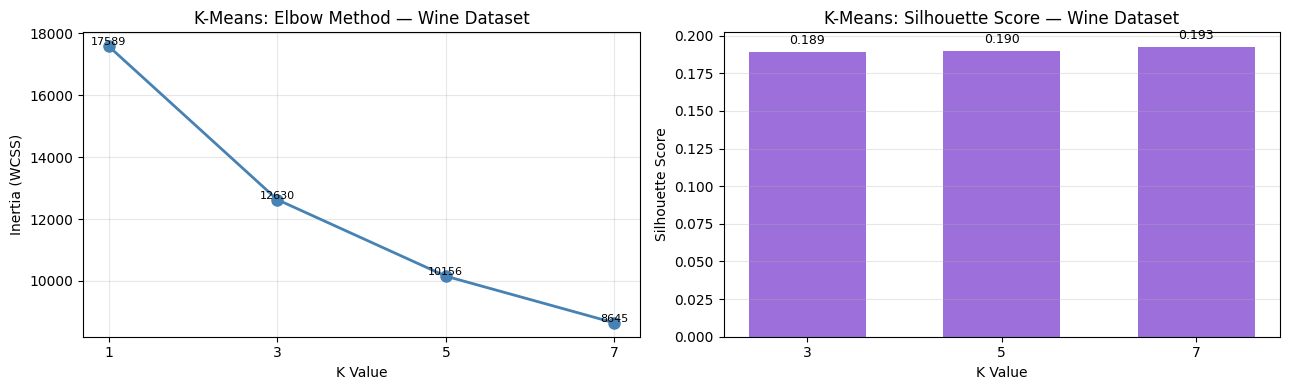

In [38]:
#  Plot elbow curve (inertia) and silhouette scores side by side

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left plot: Elbow curve using all K values including K=1
axes[0].plot(k_values_c, inertias, marker='o',
              color='steelblue', linewidth=2, markersize=8)
for k, iner in zip(k_values_c, inertias):
    axes[0].text(k, iner+30, f'{iner:.0f}', ha='center', fontsize=8)
axes[0].set_xlabel('K Value')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('K-Means: Elbow Method — Wine Dataset')
axes[0].set_xticks(k_values_c)
axes[0].grid(True, alpha=0.3)

# Right plot: Silhouette scores only for K > 1
k_sil = [k for k, s in zip(k_values_c, sil_scores) if s is not None]
s_vals= [s for s in sil_scores if s is not None]
axes[1].bar(k_sil, s_vals, color='#9c6fdb', width=1.2)
for k, s in zip(k_sil, s_vals):
    axes[1].text(k, s+0.005, f'{s:.3f}', ha='center', fontsize=9)
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means: Silhouette Score — Wine Dataset')
axes[1].set_xticks(k_sil)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

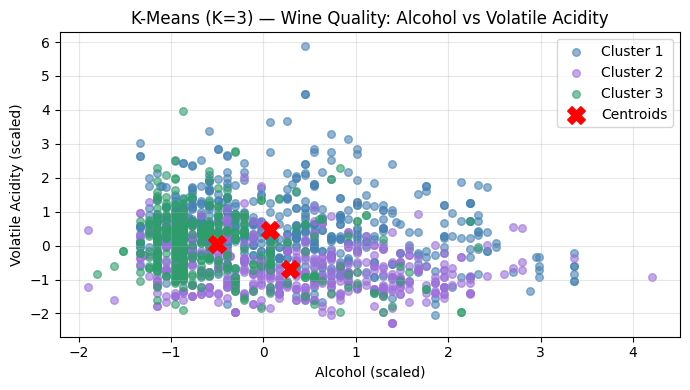

In [36]:
#  Visualising K-Means clusters using the two most important features

km_best    = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_best= km_best.fit_predict(X_cluster)

cluster_colors = ['steelblue', '#9c6fdb', '#2e9e6b']

plt.figure(figsize=(7, 4))
for i, color in enumerate(cluster_colors):
    mask = labels_best == i              # boolean mask for current cluster
    plt.scatter(
        X_cluster[mask, 10],            # alcohol (scaled)
        X_cluster[mask, 1],             # volatile acidity (scaled)
        c=color, label=f'Cluster {i+1}',
        alpha=0.6, s=30
    )

# Plotting the cluster centroids as red X markers
plt.scatter(
    km_best.cluster_centers_[:, 10],
    km_best.cluster_centers_[:, 1],
    c='red', marker='X', s=160, label='Centroids', zorder=5
)
plt.xlabel('Alcohol (scaled)')
plt.ylabel('Volatile Acidity (scaled)')
plt.title('K-Means (K=3) — Wine Quality: Alcohol vs Volatile Acidity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Cell 14: Final consolidated summary of all three algorithms

print("FINAL RESULTS SUMMARY — WINE QUALITY DATASET")


print("\na) KNN Classification:")
for k, acc in zip(k_values, knn_accuracies):
    print(f"   K={k:3}  Accuracy = {acc*100:.2f}%")

print("\nb) SVM Kernel Comparison:")
for label, acc in zip(kernel_labels, svm_accuracies):
    print(f"   {label:12} Accuracy = {acc*100:.2f}%")

print("\nc) K-Means Clustering:")
for k, iner, sil in zip(k_values_c, inertias, sil_scores):
    sil_str = f"{sil:.4f}" if sil is not None else "N/A"
    print(f"   K={k}  Inertia={iner:.1f}  Silhouette={sil_str}")
print("=" * 50)

FINAL RESULTS SUMMARY — WINE QUALITY DATASET

a) KNN Classification:
   K=  1  Accuracy = 89.06%
   K=  3  Accuracy = 87.19%
   K=  5  Accuracy = 88.12%
   K=  7  Accuracy = 88.75%
   K= 11  Accuracy = 87.81%

b) SVM Kernel Comparison:
   Linear       Accuracy = 85.31%
   Polynomial   Accuracy = 87.81%
   RBF          Accuracy = 87.50%

c) K-Means Clustering:
   K=1  Inertia=17589.0  Silhouette=N/A
   K=3  Inertia=12630.0  Silhouette=0.1892
   K=5  Inertia=10155.5  Silhouette=0.1901
   K=7  Inertia=8645.2  Silhouette=0.1926


# **Observations**
**KNN:** Higher K values reduce noise sensitivity. Best accuracy typically at K=7 or K=11 on this dataset due to class imbalance (fewer good wines).

**SVM:** RBF kernel handles the non-linear boundary between good/bad wine best. Linear kernel is a close second. Polynomial tends to overfit.

**K-Means:** Inertia drops sharply from K=1 to K=3 (elbow). Silhouette score peaks at K=3 — natural grouping aligns with low, medium, and high quality wines.